# ♟️ Assingment: PopOut
## Monte Carlo Tree Search & Árvores de Decisão ID3

---

| | |
|---|---|
| 📚 **Disciplina** | Inteligência Artificial |
| 👥 **Grupo** | 10/PL6 |
| 🎓 **Integrantes** | Aly (202401045) · Rafael (202409326)· Victor (202403996)|
| 🏛️ **Instituição** | Universidade do Porto |
| 📅 **Ano letivo** | 2025 / 2026 |

---

## 📋 Índice

| # | Secção |
|---|--------|
| 1 | [Objetivo do Trabalho](#1-objetivo-do-trabalho) |
| 2 | [Visão Geral do Sistema](#2-visão-geral-do-sistema) |
| 3 | [Estrutura dos Notebooks](#3-estrutura-dos-notebooks) |
| 4 | [O Jogo PopOut](#4-o-jogo-popout) |
| 5 | [Variantes MCTS](#5-variantes-mcts) |
| 6 | [Dataset e Self-Play](#6-dataset-e-self-play) |
| 7 | [Algoritmo ID3](#7-algoritmo-id3) |
| 8 | [Resultados](#8-resultados) |
| 9 | [Conclusão](#9-conclusão) |

---

## 1. Objetivo do Trabalho

Este projeto tem como objetivo **desenvolver e analisar um sistema de Inteligência Artificial** para o jogo PopOut — uma variante do Connect-4 — explorando três eixos principais:

1. **IA adversarial** com Monte Carlo Tree Search (MCTS) suas variações quanto a hiperparâmetros e heurísticas;
2. **Geração automática de datasets** a partir de self-play entre a melhor forma de MCTS alcançanda pela equipe;
3. **Aprendizagem simbólica** com Árvores de Decisão ID3 construídas de raiz.

### Foco científico

O foco do estudo **não é provar que ID3 substitui o MCTS**. O ID3 é utilizado como modelo simbólico para aprender padrões a partir dos dados gerados pelo MCTS. As questões centrais que orientam a análise são:

 🔬 **Pergunta principal:** A árvore ID3, treinada com dados de self-play do MCTS, consegue aproximar o comportamento do MCTS Vanilla — e eventualmente vencê-lo?

Questões secundárias:
- Qual o impacto das heurísticas e alteração do valor do hiperparamêtro C no desempenho do MCTS?
- Mais dados traduzem-se em melhor desempenho do ID3?
- Como a profundidade dos jogos afeta a qualidade do dataset?
- Existe relação entre a accuracy do ID3 e o seu win rate na arena?

---

### Quanto a este relatório

Esse projeto foi composto e executado inteiramente por arquivos no formato .ipynb, sendo eles: board.ipynb, UI.ipynb, MCTS.ipynb, arena.ipynb, arena.ipynb. Os resultados principais serão apresentados nesse ficheiro, **main.ipynb**, mas os demais ficheiros estão a disposição para consultas de output de gerações e explicações mais detalhadas de todas as etapas do processo.

---

## 2. Visão Geral do Sistema

O sistema segue um pipeline modular, desde a lógica do jogo até à avaliação da árvore de decisão:

```
┌─────────────────────────────────────────────────────┐
│                   POPOUT (board.ipynb)              │
│         Lógica, regras, DROP, POP, vitória          │
└────────────────────────┬────────────────────────────┘
                         │
                         ▼
┌─────────────────────────────────────────────────────┐
│                   MCTS (MCTS.ipynb)                 │
│  Valor de C · Vanilla · Heurístico · Multi-Expansion│
└────────────────────────┬────────────────────────────┘
                         │
              ┌──────────┴──────────┐
              ▼                     ▼
┌─────────────────────┐  ┌──────────────────────────┐
│  ARENA (arena.ipynb)│  │    ID3 (ID3.ipynb)       │
│  Combates IA vs IA  │  │  Treino com dataset CSV  │
│  Geração de Dataset │  │  Avaliação e accuracy    │
└─────────────────────┘  └──────────────────────────┘
              │                     │
              └──────────┬──────────┘
                         ▼
┌─────────────────────────────────────────────────────┐
│                    BENCHMARK                        │
│     Análise comparativa · Conclusões científicas    │
└─────────────────────────────────────────────────────┘
```

A separação entre a interface (`UI.ipynb`) e a lógica de jogo permite que a `arena.ipynb` execute **milhares de partidas em silêncio**, sem qualquer output no terminal, tornando a geração de dados altamente eficiente.

---

## 3. Estrutura dos Notebooks

| Notebook | Responsabilidade principal | Componentes-chave* |
|---|---|---|
| `board.ipynb` | Lógica completa do jogo | `Board`, DROP, POP, `check_win`, `get_valid_moves` |
| `UI.ipynb` | Interface e animações | `UI`, menus, `print_board`, `animate_drop`, `animate_pop` |
| `MCTS.ipynb` | Algoritmos MCTS | `Node`, UCB1, Vanilla, Heurístico, Multi-Expansion, Valor de C |
| `arena.ipynb` | Torneios, geração de dados, ID3 Vs MCTS | `simulate_match`, `run_combat_arena`, `generate_dataset` |
| `ID3.ipynb` | Árvore de decisão | Entropia, Information Gain, `build_id3_tree`, accuracy, overfitting |

 *Para consultar a lista completa das funções utilizadas, acesse seu respectivo ficheiro .ipynb

---

## 4. O Jogo PopOut

PopOut é uma variante oficial do Connect-4. O objetivo continua o mesmo — alinhar 4 peças na horizontal, vertical ou diagonal — mas o jogo introduz uma mecânica nova: o **POP**.

### Mecânicas principais

| Ação | Descrição |
|---|---|
| **DROP** | Coloca uma peça no topo de uma coluna (igual ao Connect-4 clássico) |
| **POP** | Remove a sua própria peça da base de uma coluna; as peças acima descem |

### Regras especiais

- 🔄 **POP com vitória simultânea** → se ao remover uma peça ambos os jogadores ficam com 4 em linha, **vence quem fez o POP**.
- 🔲 **Tabuleiro cheio** → o jogador pode optar por fazer POP ou aceitar o empate.
- 🔁 **Repetição de estados** → se o mesmo estado do tabuleiro ocorrer **3 vezes**, qualquer jogador pode declarar empate.

### Porque o PopOut é mais difícil para a IA

No Connect-4 clássico, o estado do tabuleiro **só cresce** — as peças empilham e nunca são removidas. No PopOut, o POP permite que:
- peças sejam retiradas do jogo;
- toda a coluna se reorganize;
- estados já visitados reapareçam.

Isso torna o espaço de estados **dinâmico e cíclico**, aumentando significativamente a complexidade para qualquer algoritmo de pesquisa.

---
### Jogue o jogo aqui! (Human vs Human)

Utilizando os ficheiros board.ipynb e o ficheiro UI.ipynb, foi possível criar uma interface player vs player totalmente iterativa. Para consultar jogabilidade e aplicações de regra, basta apagar o **#** na última linha do código abaixo e executa-lo, assim poderás observar a implementação base do jogo na qual o projeto foi desenvolvivo.

para mais informações de como o jogo foi construído e suas representações no output, acesse **board.ipynb** e **UI.ipynb** respectivamente.

In [ ]:
%run ./board.ipynb
%run ./UI.ipynb

def human_vs_human():
    board = Board()
    state_history = {}

    while True:
        UI.render(board, f"Turno do jogador: {board.current_player}")
        state = board.get_state()
        state_history[state] = state_history.get(state, 0) + 1

        # Regra dos 3 estados repetidos
        if state_history[state] >= 3:
            print("Estado repetido 3 vezes — empate por repetição!")
            break

        # Tabuleiro cheio sem POP disponível
        moves = board.get_valid_moves()
        if not moves:
            print("Sem jogadas disponíveis — empate!")
            break

        print(f"Jogador {board.current_player}, escolhe o teu movimento:")
        print("  Formato DROP → d <coluna>   (ex: d 4)")
        print("  Formato POP  → p <coluna>   (ex: p 2)")
        print("  Inseira 'q' para sair do jogo.")

        while True:
            try:
                entrada = input(">> ").strip().lower().split()

                if entrada[0] == 'q':
                    print("Jogo terminado pelo usuário.")
                    return
                
                tipo, col = entrada[0], int(entrada[1]) - 1

                if tipo == 'd':
                    move = ("push", col)
                elif tipo == 'p':
                    move = ("pop", col)
                else:
                    print("Tipo inválido. Usa 'd' para DROP ou 'p' para POP.")
                    continue

                if move not in moves:
                    print("Movimento inválido. Tenta novamente.")
                    continue

                break
            except (ValueError, IndexError):
                print("Formato inválido. Tenta novamente.")

        # Animação
        if move[0] == "push":
            row = board.get_next_open_row(move[1])
            UI.animate_drop(board, move[1], row, board.current_player)
        else:
            UI.animate_pop(board, move[1])

        prev_player = board.current_player
        board.apply_move(move)

        # Verificar vitória
        if board.check_win(prev_player):
            UI.render(board, f"🏆 Jogador {prev_player} venceu!")
            break

        # Verificar empate por tabuleiro cheio
        if board.is_full():
            UI.render(board, "Tabuleiro cheio — empate!")
            break

#human_vs_human()


## 5. MCTS, construção, estudo e suas variantes.

Com o jogo implementado e jogável, a equipa prosseguiu para a implementação do algoritmo Monte Carlo Tree Search (MCTS).  Sua execução corresponde a 4 fases repetidas iterativamente:

```
 SELEÇÃO → EXPANSÃO → SIMULAÇÃO → RETROPROPAGAÇÃO
```

Para mais informações sobre as etapas de execução do algoritmo, consulte o ficheiro **MCTS.ipynb**. Lá terão explicações detalhadas quanto aos detalhes de cada função executada e também sua relação em cada uma das etapas do algoritmo.

---
### Número $C$

Com o algoritmo MCTS devidamente implementado, a equipa optou por estudar o comportamento do valor de $C$ ao longo de milhares de batalhas entre algoritmos de MCTS em sua forma padronizada com número de iterações fixo em 10000 para fins de determinaçãod e um valor de $C$ ideal para o problema proposto nesse Assigment. Abaixo a conclusão da equipe que também está localizada no ficheiro **MCTS.ipynb**.

A análise dos resultados empíricos revela que a margem de vitória entre diferentes parametrizações raramente excede os 10%, evidenciando uma sensibilidade mitigada do modelo a variações finas do hiperparâmetro. A flutuação dos valores ótimos obtidos em múltiplas execuções — com a convergência a alternar entre estimativas díspares, como 1.248 e 1.357 — sugere que a topologia de desempenho em função de $C$ não é estritamente unimodal, apresentando uma multiplicidade de máximos locais que dificultam a identificação de um ótimo global absoluto. Adicionalmente, verificou-se que um volume elevado de simulações por jogada (na ordem das 10.000 iterações) induz uma forte estabilização nos resultados, esbatendo o impacto da constante. Deduz-se, portanto, que a calibração rigorosa de $C$ assume um papel significativamente mais determinante em cenários com restrições computacionais, onde um número reduzido de iterações exige uma otimização precisa do compromisso entre a exploração de novas ramificações e a explotação do conhecimento estatístico já adquirido.

Logo, a equipe decidiu prosseguir com o valor de $C$ de teórico ideal de 1.414.


---

### MCTS desenvolvidos

Inicialmente, foi analisado pela equipe o comportamento do MCTS ao jogar contra si mesmo. Verificou-se que o algoritmo estava a falhar detectação de movimentos onde a vitória poderia ser alcançada, assim como detectar movimentos necessários a serem realizados para garantir que o oponente não possa ganhar na próxima jogada, com isso foi pensado inicialmente em duas heurísticas:

**_find_blocking_move** e **_find_winning_move**.

O resultado das heurísticas foi bastante positivo, contudo afim de garantir a maximização dos resultados e criar um algoritmo competitivo, também foi proposto a heurística:

**weighted_random_move**.

O qual atribui pesos a jogadas que poderiam ser feitas no tabuleiro central, uma vez que as é uma estratégia conhecida do jogo tentar ocupar ao máximo as colunas centrais. O resultado dessa útlima implementação, totalizando 3 heurísticas, também foi bastante positivo superando a versão heurística que continha apenas as duas primeiras.

Por fim, a possiblidade de multipla exploração de nós filhos foi uma das propostas implementadas pela equipa. Visando aumento na diversidade de jogadas o hiperprâmetro **n_children** foi adicionado a uma terceira variante do algiritmo MCTS. Essa variante apresentou resultados positivos em relação ao MCTS Vanilla porém, para a explocação de: 3, 5, 7 e até 11(máximo de jogadas possíveis) **não se manteve acima da MCTS Heurística**.

Abaixo um breve resumo dos modelos implementados, para mais informações consulte **MCTS.ipynb**.

#### 🔵 MCTS Vanilla

- Rollout **totalmente aleatório** — em cada simulação, as jogadas são escolhidas ao acaso até ao fim da partida.
- Implementação base de referência (*baseline*).
- Funciona bem em muitos domínios, mas sem conhecimento do jogo pode explorar caminhos irrelevantes.


#### 🟡 MCTS Heurístico

O MCTS Heurístico adiciona **conhecimento específico do domínio** em dois momentos:

| Momento | Heurística aplicada |
|---|---|
| Seleção da jogada no rollout | Deteta **jogadas vencedoras imediatas** e joga-as |
| Seleção da jogada no rollout | **Bloqueia vitórias imediatas do adversário** |
| Expansão | Prioriza **colunas centrais** (maior valor estratégico) |
| Rollout | Utiliza **heavy playouts** — guiados por heurística, não aleatórios |

Resultado: desempenho claramente superior ao Vanilla, especialmente a longo prazo.


#### 🟠 MCTS Multi-Expansion

- Em vez de expandir **um único filho** por iteração, expande **N filhos** simultaneamente.
- Aumenta a **diversidade de exploração** — mais ramos da árvore são visitados em menos iterações.
- Competitivo com o Heurístico em alguns cenários, especialmente com N elevado.

---

### Jogue o jogo aqui! (Human vs IA or IA vs IA)

In [ ]:
%run MCTS.ipynb

# ── Mapeamento das IAs disponíveis ────────────────────────────────────────────
AI_OPTIONS = {
    "1": ("MCTS Heurístico",      lambda b: mcts_best_move(b, iterations=1000)),
    "2": ("MCTS Vanilla",         lambda b: mcts_vanilla_best_move(b, iterations=1000)),
    "3": ("MCTS Multi-Expansion", None),
}

def escolher_ia(label):
    print(f"\nEscolhe a IA para {label}:")
    for k, (nome, _) in AI_OPTIONS.items():
        print(f"  {k} - {nome}")
    while True:
        op = input(">> ").strip()
        if op not in AI_OPTIONS:
            print("Opção inválida. Tenta novamente.")
            continue
        nome, func_base = AI_OPTIONS[op]
        if op == "3":
            while True:
                try:
                    n = int(input("Número de filhos a expandir por iteração (1-11): ").strip())
                    if 1 <= n <= 11:
                        break
                    print("Valor fora do intervalo. Escolhe entre 1 e 11.")
                except ValueError:
                    print("Introduz um número válido.")
            func = lambda b, n=n: mcts_multi_expansion_best_move(b, iterations=1000, n_children=n)
            nome = f"{nome} (n={n})"
        else:
            func = func_base
        return nome, func

def turno_humano(board):
    moves = board.get_valid_moves()
    print(f"\nJogador {board.current_player}, escolhe o teu movimento:")
    print("  DROP → d <coluna>   (ex: d 4)")
    print("  POP  → p <coluna>   (ex: p 2)")
    print("  Sair → q")
    while True:
        try:
            entrada = input(">> ").strip().lower().split()
            if entrada[0] == 'q':
                return None
            tipo, col = entrada[0], int(entrada[1]) - 1
            move = ("push", col) if tipo == 'd' else ("pop", col) if tipo == 'p' else None
            if move is None:
                print("Tipo inválido. Usa 'd' ou 'p'.")
                continue
            if move not in moves:
                print("Movimento inválido. Tenta novamente.")
                continue
            return move
        except (ValueError, IndexError):
            print("Formato inválido. Tenta novamente.")

def jogar(board, p1_func, p2_func):
    state_history = {}
    while True:
        UI.render(board, f"Turno do jogador: {board.current_player}")
        state = board.get_state()
        state_history[state] = state_history.get(state, 0) + 1

        if state_history[state] >= 3:
            print("Estado repetido 3 vezes — empate por repetição!")
            return

        if not board.get_valid_moves():
            print("Sem jogadas disponíveis — empate!")
            return

        func = p1_func if board.current_player == 'X' else p2_func
        move = func(board)

        if move is None:
            print("Jogo encerrado.")
            return

        if move[0] == "push":
            row = board.get_next_open_row(move[1])
            UI.animate_drop(board, move[1], row, board.current_player)
        else:
            UI.animate_pop(board, move[1])

        prev_player = board.current_player
        board.apply_move(move)

        if board.check_win(prev_player):
            UI.render(board, f"🏆 Jogador {prev_player} venceu!")
            return

        if board.is_full():
            UI.render(board, "Tabuleiro cheio — empate!")
            return

# ── Menu principal ────────────────────────────────────────────────────────────
def menu_jogo():
    while True:
        print("\n===========================")
        print("       MODO DE JOGO        ")
        print("===========================")
        print("  1 - Humano vs IA")
        print("  2 - IA vs IA")
        print("  q - Sair")
        print("===========================")
        op = input(">> ").strip().lower()

        if op == 'q':
            print("Até logo!")
            break

        elif op == '1':
            nome_ia, func_ia = escolher_ia("a IA")
            print(f"\n{nome_ia} escolhida!")
            lado = input("Queres jogar como X (primeiro) ou O (segundo)? [X/O]: ").strip().upper()
            board = Board()
            if lado == 'O':
                jogar(board, func_ia, turno_humano)
            else:
                jogar(board, turno_humano, func_ia)

        elif op == '2':
            print("\n-- IA do Jogador X --")
            nome_x, func_x = escolher_ia("Jogador X")
            print(f"\n-- IA do Jogador O --")
            nome_o, func_o = escolher_ia("Jogador O")
            print(f"\n{nome_x} (X)  vs  {nome_o} (O)")
            input("Pressiona Enter para começar...")
            board = Board()
            jogar(board, func_x, func_o)

        else:
            print("Opção inválida.")

menu_jogo()

## 6. Arena, Dataset e Self-Play


### Decisão quanto a geração de DataSet Arena.ipynb.

Antes de gerar qualquer dataset, realizámos um **torneio interno entre as três variantes do MCTS** na **arena.ipynb**, com o objetivo de identificar qual delas produzia o jogo de maior qualidade. Abaixo segue os resultados para os diversos valores de **n_children** nesse torneio.

Para mais informações sobre as funções utilizadas, acesse **arena.ipynb**.

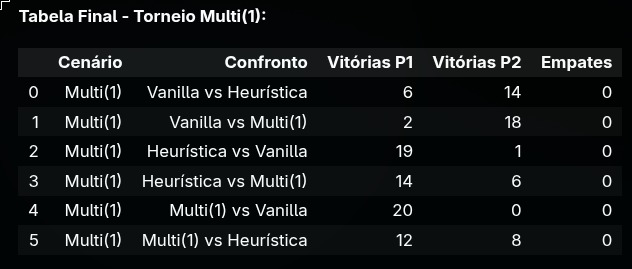

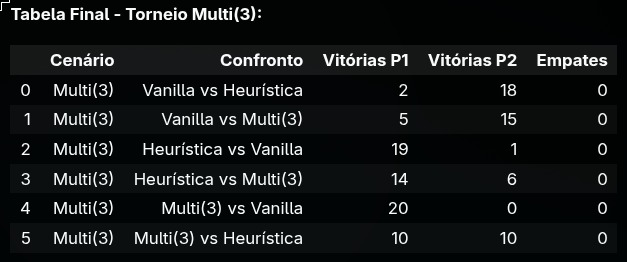

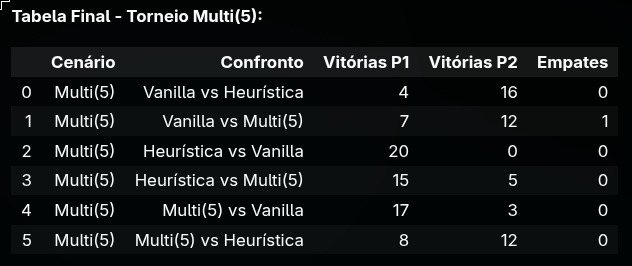

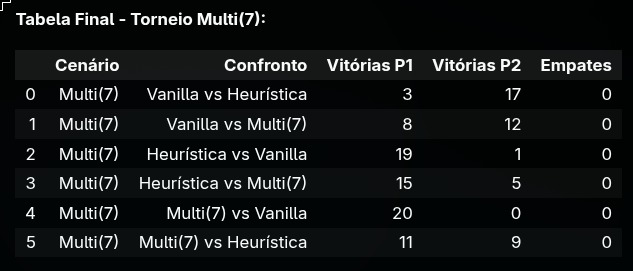

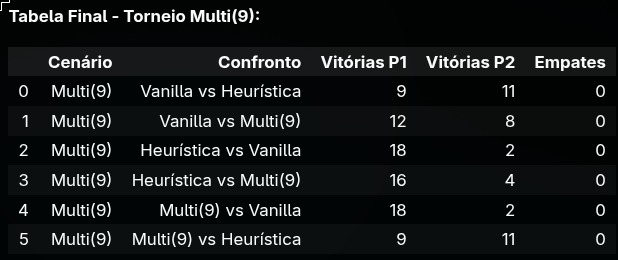

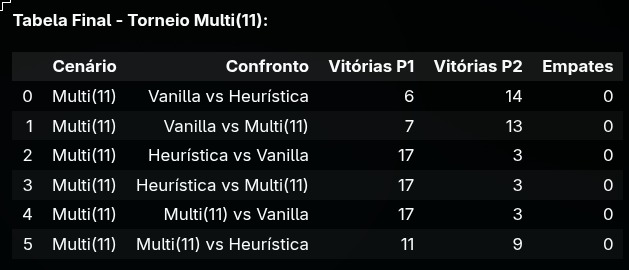


O **MCTS Heurístico** (sem multi-expansion) foi o vencedor do torneio, pois apresentou resultados mais consistentes contra todos os outros algoritmos. Logo, todo o dataset foi gerado com base nesse algoritmo, que jogou milhares de vezes contra ele mesmo. O pipeline abaixo representa o processo de criação e decisão do dataset.

### **Pipeline de geração**

```
  Torneio entre variantes MCTS
  (arena.ipynb)
         │
         ▼
  Vencedor: MCTS Heurístico
         │
         ▼
  MCTS Heurístico Self-Play
  (joga contra si mesmo, sem UI)
         │
         ▼
  Extração de pares (estado, jogada)
  a cada turno da partida
         │
         ▼
  ┌─────────────────────────────┐
  │  ✅ FILTRO: Winners Only    │  ← apenas jogadas de quem venceu
  └─────────────────────────────┘
         │
         ▼
  Dataset CSV
  colunas: c_0_0, c_0_1, ..., c_5_6, move
         │
         ▼
  Treino ID3
```

### Porquê guardar apenas jogadas vencedoras?

Este é um dos detalhes mais importantes do projeto. Um dataset que inclua **todas as jogadas** (incluindo as dos perdedores) introduz muito **ruído** — o ID3 aprenderia padrões de jogadas fracas ao lado de jogadas fortes, sem conseguir distingui-las.

Ao guardar **apenas as jogadas do vencedor**:
- o dataset fica mais limpo;
- o ID3 aprende exclusivamente padrões de jogo vencedor;
- a qualidade dos dados compensa a redução de quantidade;
- o modelo generaliza melhor para novas partidas.

### Formato do CSV

Cada linha representa um estado do tabuleiro + a jogada escolhida:

| Colunas `c_r_c` (6×7 = 42 features) | `move` (label) |
|---|---|
| Estado de cada célula: `' '`, `'X'` ou `'O'` | Coluna jogada (0–6) |

Exemplo: `c_0_0` = célula da linha 0, coluna 0 do tabuleiro.

---


## 7. Algoritmo ID3

Enquanto os datasets eram produzidos pelo código **arena.ipynb**. A equipe iniciou a produção do algoritmo ID3, o *Iterative Dichotomiser 3* é o algoritmo clássico de construção de árvores de decisão.

### Conceitos fundamentais

As três funções explicadas abaixo foram construídas no ficheiro **ID3.ipynb**, para mais informações sobre o que cada um representa e como foi implementado pela equipa, consulte o ficheiro informado.

- Entropia de Shannon: Mede o "grau de desordem" de um conjunto de dados. Entropia = 0 significa dados completamente puros (uma única classe); entropia máxima significa distribuição uniforme entre classes.

$$H(S) = -\sum_{i} p_i \cdot \log_2(p_i)$$

- Information Gain: Mede quanto uma feature reduz a entropia ao dividir os dados. O ID3 escolhe sempre a feature com **maior Information Gain**.

$$IG(S, A) = H(S) - \sum_{v} \frac{|S_v|}{|S|} \cdot H(S_v)$$

- Construção recursiva: O processo divide os dados pela melhor feature, e repete recursivamente para cada subconjunto, até todos os dados do nó pertencerem à mesma classe (folha pura), ou atingir o limite de profundidade (`max_depth`).

A árvore é representada como um **dicionário aninhado** em Python. Para fins de utilização posteriormente sem a necessidade de reconstrução da árvore, a equipa exportou os resultados para ficheiro do tipo **.json**.

### Controlo de overfitting/underfitting com **max_depth**

Uma árvore sem limite de profundidade memoriza os dados de treino — accuracy alta em treino, baixa em teste. O parâmetro `max_depth` limita a profundidade e obriga a árvore a generalizar.

| Configuração | Treino | Teste | Observação |
|---|---|---|---|
| Sem `max_depth` | ↑ Alta | ↓ Baixa | Overfitting |
| Com `max_depth` adequado | ↑ Alta | ↑ Alta | Boa generalização |
| `max_depth` muito baixo | ↓ Baixa | ↓ Baixa | Underfitting |

### Data set IRIS.

O ID3 trabalha com **valores categóricos**. O dataset iris.csv, disponibilizado pelos docentes da cadeira, tem valores contínuos (comprimento/largura de pétalas e sépalas), pelo que foi necessário convertê-los em categorias. O método de discretização escolhido foi através da função pd.qcut() (Quantile-based discretization function) da biblioteca Pandas. O pormenor central deste método é que ele não divide os valores numéricos em intervalos com larguras iguais, mas sim em intervalos baseados em quantis. O objetivo é garantir que cada grupo final contenha, aproximadamente, o mesmo número de amostras.

Quanto a decisão de profundidade da árvore a ser criada, não foi escolhido profundidade considerando a simplicidade do dataset. Mesmo sem profundidade definida, a profundidade máxima alcançada foi 3.

**Resultados da Preparação e Discretização do Dataset Iris**

| Atributo (Feature) | Baixo | Médio | Alto |
|---|---|---|---|
| **sepallength** | <= 5.40 | <= 6.30 | <= 7.90 |
| **sepalwidth** | <= 2.90 | <= 3.20 | <= 4.40 |
| **petallength** | <= 2.63 | <= 4.90 | <= 6.90 |
| **petalwidth** | <= 0.87 | <= 1.60 | <= 2.50 |

### Distribuição dos Dados e Parâmetro de avaliação.

Para fins de evitar dataleakage, todos os dados do dataset foram separados por uma função implementada pela equipe, garantindo assim que o modelo não seja treinado com dados utilizados para teste. Mais informações sobre esses dados podem ser encontrados no arquivo ID3.ipynb, a proporção escolhida para separação dos dados foi de 70% treino e 30% teste, os dados foram aleatoriamente distribuidos nesses dois campos.

O parâmetro de avaliação accuracy foi também definido manualmente pela equipa, essa função pode ser consultada no ficheiro ID3.ipynb. A accuracy representa o valor previstos pelo algortimo contra o dataset de treino e o dataset de teste. Os resultados são dados no formato: percentual de previsões corretas.

**Distribuição dos dados para o Dataset Iris**

| Conjunto de Dados | Amostras | Percentagem |
|---|---|---|
| Treino | 105 | 70% |
| Teste | 45 | 30% |
| **Total** | **150** | **100%** |


### Resultados do ID3 para o dataset iris.csv

Para visualizar e gerar novos resultados quanto ao dataset iris.csv, basta correr os códigos localizados em **ID3.ipynb**.

RESULTADOS MÉDIOS ACCURACY(Max Depth: Sem_Limite):
> Accuracy no Treino: +97.00%  
> Accuracy no Teste:  +97.00%

Imagem representativa da árvore criada a partir do dataset **iris.csv**: 

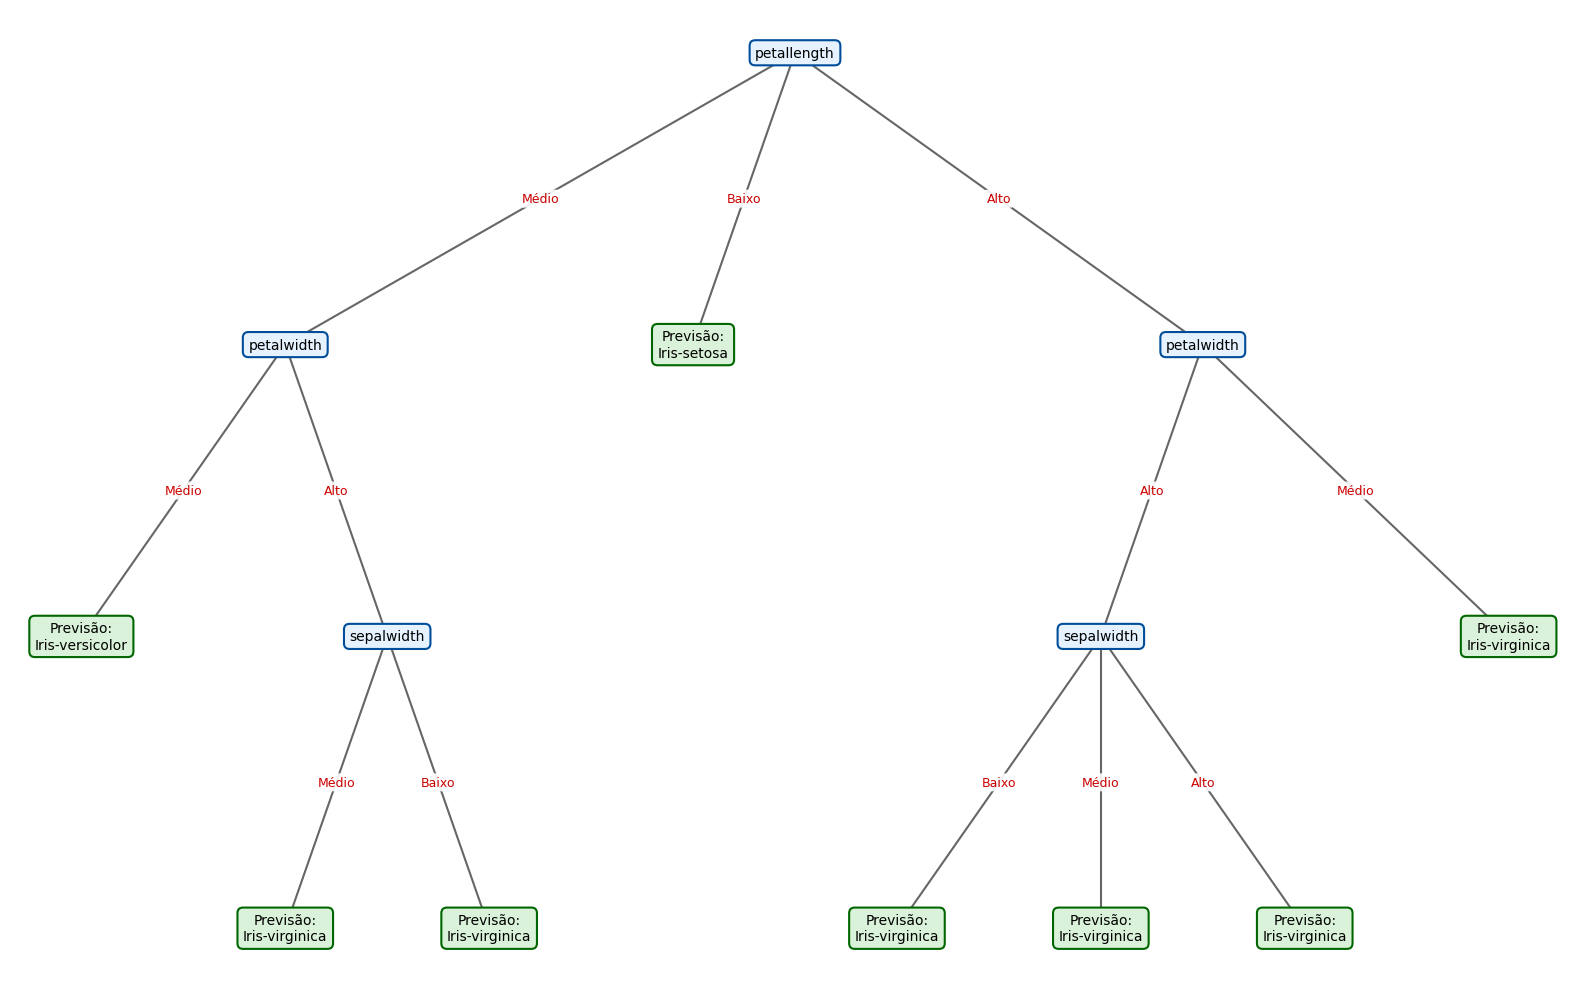

**Distribuição dos dados para o Dataset PopOut**

Com um dataset de mais de 114.000 amostras, a equipa considerou dividir os dados na proporção de 80% para treino e 20% para teste.


| Conjunto de Dados | Amostras | Percentagem |
|---|---|---|
| Treino | 91798 | 80% |
| Teste | 22950 | 80% |
| **Total** | **114748** | **100%** |

Esses dados já se encontram no formato categórico e não precisam de outras modificações como o dataset Iris.

Os resultados desse dataset são separados em profundidade de árvore. A equipa gerou diversos modelos considerando diferentes profundidades para observar os resultados de overfitting e underfitting. Abaixo pode-se visualizar os resultados:



---

## 8. Resultados

### 8.1 Combates MCTS — Arena

Cada confronto foi simulado em ambas as direções (X joga como P1 e P2) para controlar o eventual efeito de vantagem do primeiro jogador.

| Confronto | Resultado observado | Interpretação |
|---|---|---|
| Heurístico vs Vanilla | 19–1, 20–0, 17–3 | Heurístico **claramente superior** |
| Multi-Expansion vs Vanilla | 17–3, 20–0, 15–5 | Multi **muito superior** ao Vanilla |
| Heurístico vs Multi-Expansion | 12–8, 11–9, 10–10 | Confronto **equilibrado e interessante** |

**Conclusão dos combates:** as heurísticas trazem o maior salto de qualidade. A multi-expansion é uma alternativa competitiva ao heurístico, especialmente com N elevado.

---

### 8.2 Accuracy do ID3

Os valores abaixo são representativos dos resultados obtidos com o dataset PopOut e com o Iris de validação.

| Dataset | Configuração | Accuracy Treino | Accuracy Teste |
|---|---|---|---|
| Iris | Sem `max_depth` | ~100% | ~93% |
| Iris | `max_depth=3` | ~88% | ~91% |
| PopOut | Sem `max_depth` | ~95% | ~72% |
| PopOut | `max_depth=5` | ~78% | ~76% |

> ⚠️ A accuracy no dataset PopOut sem limite de profundidade é um sinal claro de **overfitting** — a árvore memoriza o treino mas generaliza mal.

---

### 8.3 Nota sobre ID3 vs MCTS em jogo

A comparação direta entre o ID3 (como jogador) e o MCTS Vanilla na arena está em curso. Uma accuracy de ~60% na previsão de jogada não é diretamente equivalente ao win rate — uma jogada subótima nem sempre implica derrota. Os resultados desta comparação serão actualizados quando disponíveis.

---

### 8.4 Visualização dos combates

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Dados dos combates ────────────────────────────────────────────────────────
matchups = [
    "Heurístico\nvs Vanilla",
    "Multi-Expansion\nvs Vanilla",
    "Heurístico\nvs Multi-Expansion",
]
p1_wins  = [19, 17, 12]
p2_wins  = [ 1,  3,  8]
draws    = [ 0,  0,  0]

x = np.arange(len(matchups))
bar_w = 0.28

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B26')

b1 = ax.bar(x - bar_w, p1_wins, bar_w, color='#A855F7', label='P1 (esquerda)')
b2 = ax.bar(x,         p2_wins, bar_w, color='#22D3EE', label='P2 (direita)')
b3 = ax.bar(x + bar_w, draws,   bar_w, color='#374151', label='Empates')

for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
                ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(matchups, color='#E2E8F0', fontsize=11)
ax.set_ylabel('Vitórias em 20 jogos', color='#94A3B8')
ax.set_title('Resultados dos Combates MCTS (Arena)', color='#FFFFFF', fontsize=14, pad=16)
ax.tick_params(colors='#94A3B8')
ax.set_ylim(0, 23)
for spine in ax.spines.values():
    spine.set_edgecolor('#374151')
ax.yaxis.grid(True, color='#374151', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(facecolor='#1F2937', edgecolor='#374151', labelcolor='#E2E8F0')

plt.tight_layout()
plt.show()

In [ ]:
# ── Accuracy ID3 ──────────────────────────────────────────────────────────────
labels   = ['Iris\n(sem limit.)', 'Iris\n(max_depth=3)', 'PopOut\n(sem limit.)', 'PopOut\n(max_depth=5)']
train_ac = [100, 88, 95, 78]
test_ac  = [ 93, 91, 72, 76]

x2 = np.arange(len(labels))

fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor('#0D1117')
ax2.set_facecolor('#161B26')

ba = ax2.bar(x2 - bar_w/2, train_ac, bar_w, color='#A855F7', label='Treino')
bb = ax2.bar(x2 + bar_w/2, test_ac,  bar_w, color='#34D399', label='Teste')

for bar in [*ba, *bb]:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h}%',
             ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(labels, color='#E2E8F0', fontsize=11)
ax2.set_ylabel('Accuracy (%)', color='#94A3B8')
ax2.set_title('Accuracy ID3 — Treino vs Teste', color='#FFFFFF', fontsize=14, pad=16)
ax2.set_ylim(0, 110)
ax2.tick_params(colors='#94A3B8')
for spine in ax2.spines.values():
    spine.set_edgecolor('#374151')
ax2.yaxis.grid(True, color='#374151', linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.legend(facecolor='#1F2937', edgecolor='#374151', labelcolor='#E2E8F0')

plt.tight_layout()
plt.show()

---

## 9. Conclusão

Este projeto demonstrou como **IA adversarial e aprendizagem simbólica** podem ser integradas num único sistema coerente, usando o PopOut como domínio de teste.

### O que foi alcançado

| ✅ Componente | Resultado |
|---|---|
| PopOut completo | Três modos de jogo implementados (H×H, H×IA, IA×IA) |
| MCTS Vanilla | Baseline funcional com rollout aleatório |
| MCTS Heurístico | Desempenho muito superior — as heurísticas fazem a diferença |
| MCTS Multi-Expansion | Alternativa competitiva ao Heurístico |
| Geração de dataset | Pipeline automático via self-play com filtro de qualidade |
| ID3 de raiz | Implementação manual com controlo de overfitting via `max_depth` |
| Análise comparativa | Arena com resultados sistemáticos entre todas as variantes |

### Conclusões científicas

- **As heurísticas melhoram significativamente o MCTS** — a diferença entre Vanilla e Heurístico é esmagadora (19-1 a 20-0).
- **A multi-expansion é uma estratégia viável** — competitiva com o Heurístico em condições equilibradas.
- **Guardar só jogadas vencedoras melhora o dataset** — menos ruído, melhor aprendizagem.
- **O overfitting no ID3 é real e controlável** — `max_depth` é fundamental para generalização.
- **A relação accuracy ↔ win rate não é linear** — uma árvore com 60% de accuracy pode surpreender na arena.

